# **K-means**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Download the Mall Customer dataset directly
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#Inspect data
print(df.shape)
print(df.info())
df.describe()

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
#select features and scale
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

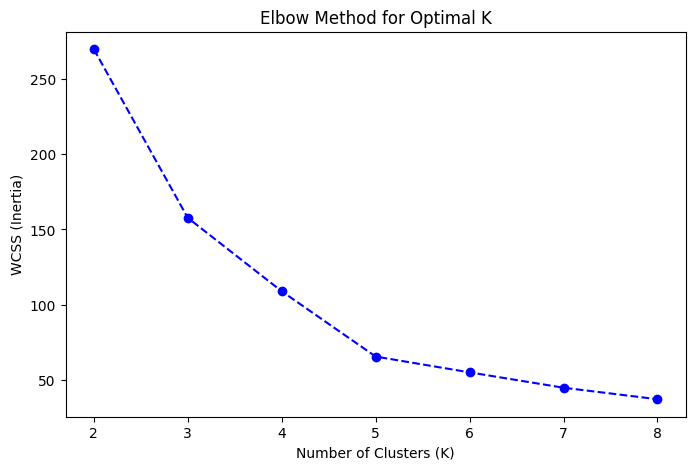

In [5]:
#elbow method
wcss = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(list(K_range))
plt.show()

In [6]:
#fit final model with chosen K
optimal_k = 5  # based on elbow curve above

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled) #trains and assigns cluster labels in one step.

df['Cluster'] = cluster_labels
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


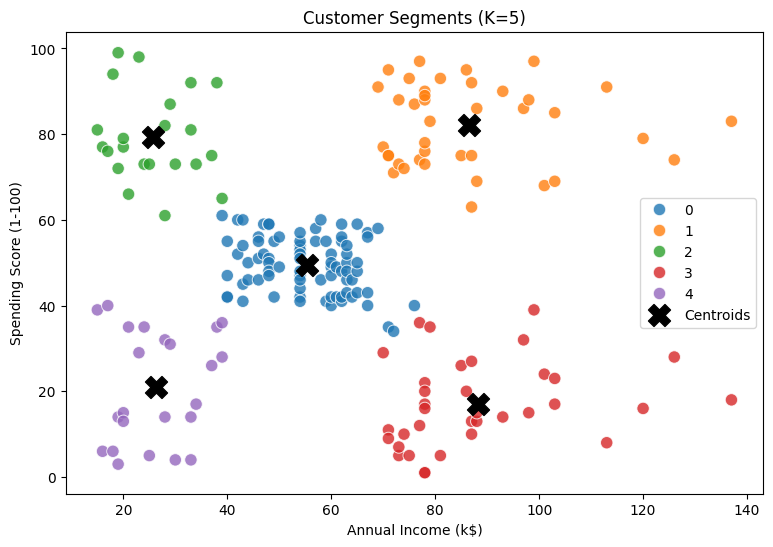

In [7]:
#visualizing the clusters
plt.figure(figsize=(9, 6))

centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)

sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='tab10', s=80, alpha=0.8
)
plt.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    s=250, c='black', marker='X', label='Centroids'
)
plt.title(f'Customer Segments (K={optimal_k})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [11]:
#Evaluate Using Silhouette Score
score = silhouette_score(X_scaled, cluster_labels)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.555


In [12]:
#Business Interpretation
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


In [16]:
# assign labels
label_map = {
    0: 'Standard (Mid Income, Mid Spend)',
    1: 'Target (High Income, High Spend)',
    2: 'Careless (Low Income, High Spend)',
    3: 'Careful (High Income, Low Spend)',
    4: 'Sensible (Low Income, Low Spend)'
}

df['Segment'] = df['Cluster'].map(label_map)
df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Segment']].head(10)

,CustomerID,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,15,39,4,"Sensible (Low Income, Low Spend)"
1,2,15,81,2,"Careless (Low Income, High Spend)"
2,3,16,6,4,"Sensible (Low Income, Low Spend)"
3,4,16,77,2,"Careless (Low Income, High Spend)"
4,5,17,40,4,"Sensible (Low Income, Low Spend)"
5,6,17,76,2,"Careless (Low Income, High Spend)"
6,7,18,6,4,"Sensible (Low Income, Low Spend)"
7,8,18,94,2,"Careless (Low Income, High Spend)"
8,9,19,3,4,"Sensible (Low Income, Low Spend)"
9,10,19,72,2,"Careless (Low Income, High Spend)"


# **Final Summary:**

K-Means clustering was successfully applied to segment mall customers based on their Annual Income and Spending Score. Using the Elbow Method, the optimal number of clusters was identified as K = 5, resulting in five meaningful customer groups with distinct purchasing behaviors. The model achieved a Silhouette Score of 0.555, indicating reasonably well-defined and moderately separated clusters. These customer segments can help businesses better understand their customers, develop targeted marketing strategies, and improve customer engagement through personalized offers.